<a href="https://colab.research.google.com/github/bhavyatha-21/secure-sync/blob/main/Secure_sync.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

import matplotlib.pyplot as plt


# ============================================================
# 1. INPUT: FIVE WEB PAGES
# ============================================================

pages = [
    """
    Artificial intelligence and machine learning are transforming
    healthcare. Machine learning algorithms can analyze medical data,
    improve diagnosis, and support healthcare technology.
    """,

    """
    Machine learning uses algorithms, data, artificial intelligence,
    and statistical methods. Machine learning models are used for
    prediction, classification, and data analysis.
    """,

    """
    Cricket is a popular sport played between teams. Sports news
    includes cricket matches, players, tournaments, scores, and
    sports results.
    """,

    """
    Artificial intelligence and robotics are developing rapidly.
    AI systems, robots, machine learning, automation, and intelligent
    technologies are used in modern industries.
    """,

    """
    Healthcare technology uses artificial intelligence and data
    analysis to improve medical services. AI can support doctors,
    medical diagnosis, healthcare systems, and patient care.
    """
]


page_names = [
    "Page 1",
    "Page 2",
    "Page 3",
    "Page 4",
    "Page 5"
]


# ============================================================
# 2. TEXT → TF-IDF WORD VECTORS
# ============================================================

vectorizer = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(pages)

print("\nTF-IDF Matrix Shape:")
print(tfidf_matrix.shape)

print("\nVocabulary:")
print(vectorizer.get_feature_names_out())


# ============================================================
# 3. COSINE SIMILARITY MATRIX
# ============================================================

similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=page_names,
    columns=page_names
)

print("\n====================================")
print("COSINE SIMILARITY MATRIX")
print("====================================")

print(similarity_df.round(3))


# ============================================================
# 4. EIGENVALUE CENTRALITY
# ============================================================

# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(similarity_matrix)

# Find index of largest eigenvalue
largest_index = np.argmax(eigenvalues)

largest_eigenvalue = eigenvalues[largest_index]

# Corresponding eigenvector
centrality_vector = eigenvectors[:, largest_index]

# Eigenvectors can contain negative signs.
# Make the vector positive for ranking.
if np.sum(centrality_vector) < 0:
    centrality_vector = -centrality_vector

# Normalize scores
centrality_scores = centrality_vector / np.sum(centrality_vector)


# Create Eigenvalue ranking
eigen_df = pd.DataFrame({
    "Page": page_names,
    "Eigenvalue Score": centrality_scores
})

eigen_df = eigen_df.sort_values(
    "Eigenvalue Score",
    ascending=False
).reset_index(drop=True)

eigen_df["Eigen Rank"] = np.arange(
    1, len(eigen_df) + 1
)


print("\n====================================")
print("EIGENVALUE CENTRALITY")
print("====================================")

print("Largest Eigenvalue:")
print(round(largest_eigenvalue, 4))

print("\nEigenvalue Ranking:")
print(eigen_df.round(4))


# ============================================================
# 5. SVD
# ============================================================

# Number of latent components
# Maximum possible components for 5 documents is 5,
# but we use 3 for easier interpretation.
k = min(3, tfidf_matrix.shape[0], tfidf_matrix.shape[1])

svd = TruncatedSVD(
    n_components=k,
    random_state=42
)

U = svd.fit_transform(tfidf_matrix)

singular_values = svd.singular_values_

Vt = svd.components_


# ============================================================
# 6. SVD PAGE SCORES
# ============================================================

# U contains document coordinates in latent space.
# Multiply each component by its singular value.

document_topic_matrix = U * singular_values

# Calculate magnitude of each page in latent space
svd_scores = np.linalg.norm(
    document_topic_matrix,
    axis=1
)

svd_df = pd.DataFrame({
    "Page": page_names,
    "SVD Score": svd_scores
})

svd_df = svd_df.sort_values(
    "SVD Score",
    ascending=False
).reset_index(drop=True)

svd_df["SVD Rank"] = np.arange(
    1,
    len(svd_df) + 1
)


print("\n====================================")
print("SVD RESULTS")
print("====================================")

print("\nSingular Values:")
for i, value in enumerate(singular_values):
    print(
        f"Component {i + 1}: {value:.4f}"
    )

print("\nExplained Variance Ratio:")
for i, value in enumerate(
    svd.explained_variance_ratio_
):
    print(
        f"Component {i + 1}: {value:.4f}"
    )

print("\nSVD Ranking:")
print(svd_df.round(4))


# ============================================================
# 7. COMPARE BOTH RANKINGS
# ============================================================

comparison = pd.merge(
    eigen_df[["Page", "Eigen Rank"]],
    svd_df[["Page", "SVD Rank"]],
    on="Page"
)

comparison["Rank Difference"] = (
    comparison["Eigen Rank"]
    - comparison["SVD Rank"]
).abs()

comparison


TF-IDF Matrix Shape:
(5, 50)

Vocabulary:
['ai' 'algorithms' 'analysis' 'analyze' 'artificial' 'automation' 'care'
 'classification' 'cricket' 'data' 'developing' 'diagnosis' 'doctors'
 'healthcare' 'improve' 'includes' 'industries' 'intelligence'
 'intelligent' 'learning' 'machine' 'matches' 'medical' 'methods' 'models'
 'modern' 'news' 'patient' 'played' 'players' 'popular' 'prediction'
 'rapidly' 'results' 'robotics' 'robots' 'scores' 'services' 'sport'
 'sports' 'statistical' 'support' 'systems' 'teams' 'technologies'
 'technology' 'tournaments' 'transforming' 'used' 'uses']

COSINE SIMILARITY MATRIX
        Page 1  Page 2  Page 3  Page 4  Page 5
Page 1   1.000   0.431     0.0   0.189   0.531
Page 2   0.431   1.000     0.0   0.236   0.195
Page 3   0.000   0.000     1.0   0.000   0.000
Page 4   0.189   0.236     0.0   1.000   0.139
Page 5   0.531   0.195     0.0   0.139   1.000

EIGENVALUE CENTRALITY
Largest Eigenvalue:
1.902

Eigenvalue Ranking:
     Page  Eigenvalue Score  Eigen 

,Page,Eigen Rank,SVD Rank,Rank Difference
0,Page 1,1,1,0
1,Page 5,2,2,0
2,Page 2,3,5,2
3,Page 4,4,4,0
4,Page 3,5,3,2


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

# Enter 5 web page contents
pages = [
    "Artificial intelligence and machine learning are transforming healthcare. "
    "Machine learning algorithms analyze medical data and improve diagnosis.",

    "Machine learning uses algorithms, artificial intelligence, data science "
    "and statistical methods for prediction and classification.",

    "Cricket is a popular sport. Sports news includes cricket matches, players, "
    "tournaments, scores and sports results.",

    "Artificial intelligence and robotics are developing rapidly. "
    "AI, robots, machine learning and automation are used in modern industries.",

    "Healthcare technology uses artificial intelligence and data analysis "
    "to improve medical services, diagnosis and patient care."
]

page_names = ["Page 1", "Page 2", "Page 3", "Page 4", "Page 5"]

print("Number of web pages:", len(pages))

Number of web pages: 5


TF-IDF Matrix Shape: (5, 43)

COSINE SIMILARITY MATRIX


,Page 1,Page 2,Page 3,Page 4,Page 5
Page 1,1.000,0.389,0.0,0.238,0.383
Page 2,0.389,1.000,0.0,0.164,0.197
Page 3,0.000,0.000,1.0,0.000,0.000
Page 4,0.238,0.164,0.0,1.000,0.064
Page 5,0.383,0.197,0.0,0.064,1.000


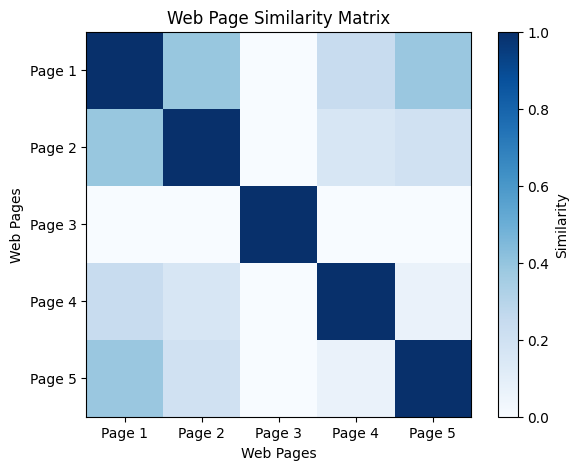

In [ ]:
# Convert web page text into TF-IDF vectors
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(pages)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

# Calculate cosine similarity
similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=page_names,
    columns=page_names
)

print("\nCOSINE SIMILARITY MATRIX")
display(similarity_df.round(3))

# Heatmap
plt.figure(figsize=(7, 5))
plt.imshow(similarity_matrix, cmap="Blues")
plt.colorbar(label="Similarity")

plt.xticks(range(5), page_names)
plt.yticks(range(5), page_names)

plt.title("Web Page Similarity Matrix")
plt.xlabel("Web Pages")
plt.ylabel("Web Pages")

plt.show()

Largest Eigenvalue: 1.7558

EIGENVALUE CENTRALITY RANKING


,Page,Eigenvalue Score,Eigen Rank
0,Page 1,0.3151,1
1,Page 2,0.2642,2
2,Page 5,0.2436,3
3,Page 4,0.1770,4
4,Page 3,0.0000,5


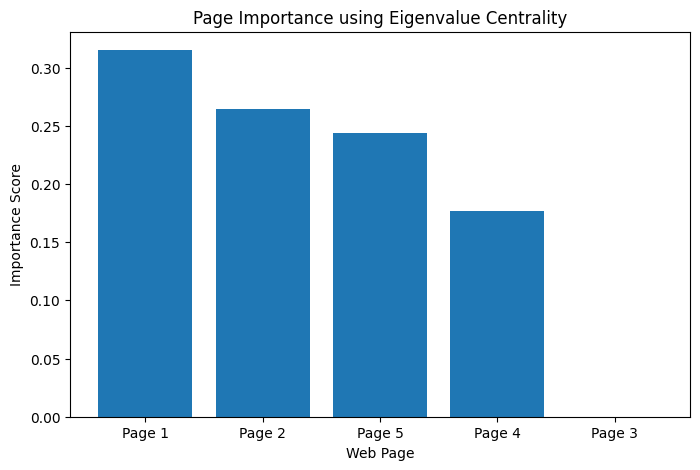

In [ ]:
# Find eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(similarity_matrix)

# Find the largest eigenvalue
index = np.argmax(eigenvalues)

largest_eigenvalue = eigenvalues[index]

# Corresponding eigenvector
centrality = eigenvectors[:, index]

# Make scores positive
if np.sum(centrality) < 0:
    centrality = -centrality

# Normalize scores
centrality = centrality / np.sum(centrality)

# Create ranking table
eigen_result = pd.DataFrame({
    "Page": page_names,
    "Eigenvalue Score": centrality
})

eigen_result = eigen_result.sort_values(
    "Eigenvalue Score",
    ascending=False
).reset_index(drop=True)

eigen_result["Eigen Rank"] = range(1, 6)

print("Largest Eigenvalue:", round(largest_eigenvalue, 4))

print("\nEIGENVALUE CENTRALITY RANKING")
display(eigen_result.round(4))

# Plot
plt.figure(figsize=(8, 5))

plt.bar(
    eigen_result["Page"],
    eigen_result["Eigenvalue Score"]
)

plt.title("Page Importance using Eigenvalue Centrality")
plt.xlabel("Web Page")
plt.ylabel("Importance Score")

plt.show()

SINGULAR VALUES
Topic 1: 1.3251
Topic 2: 1.0000
Topic 3: 0.9713

Explained Variance Ratio
Topic 1: 0.1180
Topic 2: 0.2335
Topic 3: 0.2720

SVD PAGE RANKING


,Page,SVD Score,SVD Rank
0,Page 1,1.0881,1
1,Page 3,1.0000,2
2,Page 4,0.9942,3
3,Page 5,0.9851,4
4,Page 2,0.9110,5


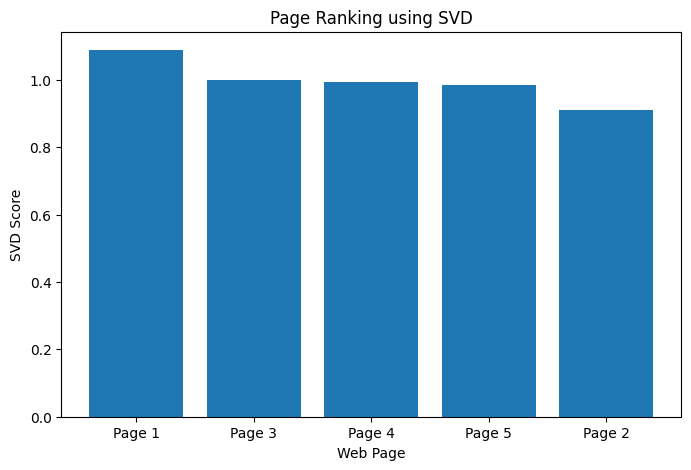

In [ ]:
# Number of latent topics/components
k = 3

svd = TruncatedSVD(
    n_components=k,
    random_state=42
)

# U-like document representation
U = svd.fit_transform(tfidf_matrix)

# Singular values
singular_values = svd.singular_values_

# Topic-word matrix
Vt = svd.components_

print("SINGULAR VALUES")

for i, value in enumerate(singular_values):
    print(f"Topic {i + 1}: {value:.4f}")

print("\nExplained Variance Ratio")

for i, value in enumerate(svd.explained_variance_ratio_):
    print(f"Topic {i + 1}: {value:.4f}")

# Calculate SVD page scores
document_topic_matrix = U * singular_values

svd_scores = np.linalg.norm(
    document_topic_matrix,
    axis=1
)

# Ranking
svd_result = pd.DataFrame({
    "Page": page_names,
    "SVD Score": svd_scores
})

svd_result = svd_result.sort_values(
    "SVD Score",
    ascending=False
).reset_index(drop=True)

svd_result["SVD Rank"] = range(1, 6)

print("\nSVD PAGE RANKING")
display(svd_result.round(4))

# Plot
plt.figure(figsize=(8, 5))

plt.bar(
    svd_result["Page"],
    svd_result["SVD Score"]
)

plt.title("Page Ranking using SVD")
plt.xlabel("Web Page")
plt.ylabel("SVD Score")

plt.show()

EIGENVALUE vs SVD RANKING


,Page,Eigen Rank,SVD Rank,Rank Difference
0,Page 1,1,1,0
1,Page 2,2,5,3
2,Page 5,3,4,1
3,Page 4,4,3,1
4,Page 3,5,2,3


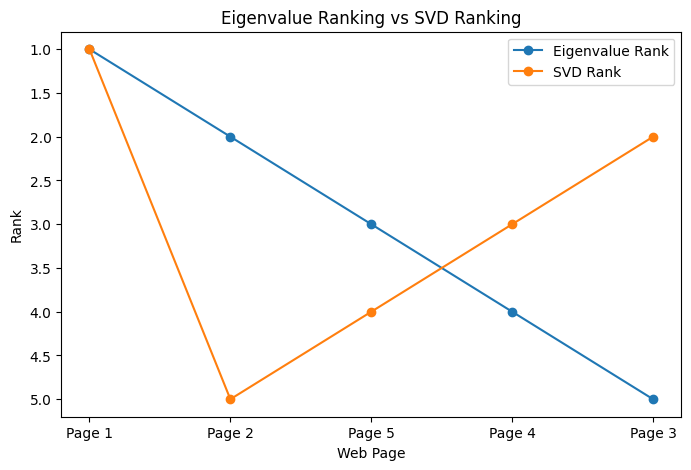


PROJECT CONCLUSION
------------------
Top page according to Eigenvalue: Page 1
Top page according to SVD: Page 1

The Eigenvalue method measures page centrality
using the similarity network.

The SVD method identifies latent mathematical
patterns/topics and ranks pages according to
their strength in the latent space.


In [ ]:
# Merge both rankings
comparison = pd.merge(
    eigen_result[["Page", "Eigen Rank"]],
    svd_result[["Page", "SVD Rank"]],
    on="Page"
)

# Difference between rankings
comparison["Rank Difference"] = (
    comparison["Eigen Rank"] -
    comparison["SVD Rank"]
).abs()

comparison = comparison.sort_values("Eigen Rank")

print("EIGENVALUE vs SVD RANKING")
display(comparison)

# Plot comparison
plt.figure(figsize=(8, 5))

plt.plot(
    comparison["Page"],
    comparison["Eigen Rank"],
    marker="o",
    label="Eigenvalue Rank"
)

plt.plot(
    comparison["Page"],
    comparison["SVD Rank"],
    marker="o",
    label="SVD Rank"
)

plt.xlabel("Web Page")
plt.ylabel("Rank")
plt.title("Eigenvalue Ranking vs SVD Ranking")

plt.gca().invert_yaxis()
plt.legend()

plt.show()

# Final conclusion
print("\nPROJECT CONCLUSION")
print("------------------")

best_eigen = eigen_result.iloc[0]["Page"]
best_svd = svd_result.iloc[0]["Page"]

print("Top page according to Eigenvalue:", best_eigen)
print("Top page according to SVD:", best_svd)

print("\nThe Eigenvalue method measures page centrality")
print("using the similarity network.")

print("\nThe SVD method identifies latent mathematical")
print("patterns/topics and ranks pages according to")
print("their strength in the latent space.")